# Rock, Paper, Scissors Classification Model
- 3 classes/poses: rock, paper, scissors
  - 1 sample has 5 * 6  features (for now)?
- Classification neural net

https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/02_pytorch_classification.ipynb#scrollTo=Z2gcR31aHC78

## Ablation

https://docs.google.com/spreadsheets/d/1Xy92hWhrxcyvLkxY7Q0RPff1FNVfsLxV0ujrjC6SdFE/edit?gid=427952541#gid=427952541

In [359]:
from sklearn.metrics._plot.confusion_matrix import confusion_matrix
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import asyncio
import websockets
import json

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, LabelBinarizer, MinMaxScaler

In [360]:
print(torch.__version__)
print(torch._dynamo.__file__)

2.6.0+cu124
/mnt/c/Users/j15t3/Documents/Programming/Capstone/.venv/lib/python3.12/site-packages/torch/_dynamo/__init__.py


In [361]:
EPOCHS = 300
SEED = 40

STD = 0.02
COPY = 5
HIDDEN = 0 # No consistent hidden layers in other models
DROPOUT = 0.1

# Set BATCH_SIZE to the full training dataset size for now
# BATCH_SIZE = len(X_train)
LR = 1e-3

N_FOLDS = 5

In [362]:
df = pd.read_csv("data/Glove_v2_norm/output_norm_train.csv")
df = df.drop(columns=["time"], errors='ignore')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32289 entries, 0 to 32288
Data columns (total 55 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   BNO0_UnitAccX   32289 non-null  float64
 1   BNO0_UnitAccY   32289 non-null  float64
 2   BNO0_UnitAccZ   32289 non-null  float64
 3   BNO0_RawAccMag  32289 non-null  float64
 4   BNO0_GyrX       32289 non-null  float64
 5   BNO0_GyrY       32289 non-null  float64
 6   BNO0_GyrZ       32289 non-null  float64
 7   BNO0_MagX       32289 non-null  float64
 8   BNO0_MagY       32289 non-null  float64
 9   BNO0_MagZ       32289 non-null  float64
 10  BNO1_UnitAccX   32289 non-null  float64
 11  BNO1_UnitAccY   32289 non-null  float64
 12  BNO1_UnitAccZ   32289 non-null  float64
 13  BNO1_RawAccMag  32289 non-null  float64
 14  BNO1_GyrX       32289 non-null  float64
 15  BNO1_GyrY       32289 non-null  float64
 16  BNO1_GyrZ       32289 non-null  float64
 17  BNO1_MagX       32289 non-null  float64
 1

In [363]:
# # def augment_with_noise(df, label_col="label", noise_std=0.01, copies=3):
#     feature_cols = df.drop(columns=[label_col]).columns
#     augmented_dfs = [df]  # keep original

#     for i in range(copies):

#         noisy_df = df.copy()

#         noise = np.random.normal(
#             loc=0,
#             scale=noise_std,
#             size=noisy_df[feature_cols].shape
#         )

#         noisy_df[feature_cols] = noisy_df[feature_cols] + noise

#         augmented_dfs.append(noisy_df)

#     return pd.concat(augmented_dfs, ignore_index=True)

In [364]:
def augment_with_noise(df, label_col="label", noise_fraction=0.05, copies=3, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
        
    # Isolate only numeric columns, ignoring the label
    features_df = df.drop(columns=[label_col], errors='ignore')
    numeric_cols = features_df.select_dtypes(include=[np.number]).columns
    
    augmented_dfs = [df]  # keep original

    # Calculate the standard deviation for each numeric column
    col_stds = df[numeric_cols].std().values

    for _ in range(copies):
        noisy_df = df.copy()
        
        # Generate noise proportional to each column's standard deviation
        noise = np.random.normal(
            loc=0,
            scale=col_stds * noise_fraction, 
            size=(len(df), len(numeric_cols))
        )
        
        noisy_df[numeric_cols] = noisy_df[numeric_cols] + noise
        augmented_dfs.append(noisy_df)

    return pd.concat(augmented_dfs, ignore_index=True)

In [365]:
# df = df[df['label'] != "none"]

In [366]:
# 1. Split FIRST to prevent data leakage. 
# stratify=df['label'] ensures the 1000 test rows have the correct class proportions.
df_train, testing = train_test_split(df, test_size=1000, stratify=df['label'], random_state=42)

# Reset indices for cleanliness
df_train = df_train.reset_index(drop=True)
testing = testing.reset_index(drop=True)

# 2. Balance the TRAINING data only
min_count = df_train['label'].value_counts().min()
df_balanced = df_train.groupby('label').sample(n=min_count, random_state=42).reset_index(drop=True)

print("Balanced Training Class Counts:")
print(df_balanced['label'].value_counts())

# Now 'df_balanced' is ready for your augment_with_noise() function!
df = df_balanced

Balanced Training Class Counts:
label
none        4727
paper       4727
rock        4727
scissors    4727
Name: count, dtype: int64


In [367]:

# Print original size with context
print(f"Original row count: {len(df)}")

augmented_df = augment_with_noise(
    df,
    label_col="label",
    noise_fraction=0.0005, # Using the updated parameter from the previous cell
    copies=COPY,
    random_state=42      # Using the new reproducibility parameter
)

print(f"Augmented row count: {len(augmented_df)}")

# If you must overwrite df to save memory, do it at the very end
df = augmented_df

Original row count: 18908
Augmented row count: 113448


In [368]:
df.head()

,BNO0_UnitAccX,BNO0_UnitAccY,BNO0_UnitAccZ,BNO0_RawAccMag,BNO0_GyrX,BNO0_GyrY,BNO0_GyrZ,BNO0_MagX,BNO0_MagY,BNO0_MagZ,...,MPU0_GyrY,MPU0_GyrZ,MPU1_UnitAccX,MPU1_UnitAccY,MPU1_UnitAccZ,MPU1_RawAccMag,MPU1_GyrX,MPU1_GyrY,MPU1_GyrZ,label
0,-0.008,-0.475,-0.88,2034.57,182.966,48.791,-18.688,0.032,0.013,0.999,...,0.641,-1.756,0.259,0.639,-0.724,10.567,-6.931,-3.405,0.046,none
1,-0.008,-0.475,-0.88,2034.57,182.966,48.791,-18.688,0.032,0.013,0.999,...,0.031,-1.511,0.254,0.617,-0.745,10.574,-5.435,-4.977,-1.053,none
2,-0.008,-0.475,-0.88,2034.57,182.966,48.791,-18.688,0.032,0.013,0.999,...,-0.122,-1.237,0.901,0.429,0.060,10.485,-5.573,-4.962,-0.702,none
3,-0.008,-0.475,-0.88,2034.57,182.966,48.791,-18.688,0.032,0.013,0.999,...,-0.076,-1.466,0.265,0.607,-0.749,10.585,-5.313,-4.840,-0.641,none
4,-0.008,-0.475,-0.88,2034.57,182.966,48.791,-18.688,0.032,0.013,0.999,...,-0.076,-1.450,0.899,0.433,0.069,10.512,-5.664,-4.901,-0.855,none


In [369]:
df_train  = df
df_train.label.value_counts()

label
none        28362
paper       28362
rock        28362
scissors    28362
Name: count, dtype: int64

## Make data and label dfs


In [370]:
# Scramble the rows
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
# df_all = df_all.drop(columns=["time"])
df_train.head(3)

,BNO0_UnitAccX,BNO0_UnitAccY,BNO0_UnitAccZ,BNO0_RawAccMag,BNO0_GyrX,BNO0_GyrY,BNO0_GyrZ,BNO0_MagX,BNO0_MagY,BNO0_MagZ,...,MPU0_GyrY,MPU0_GyrZ,MPU1_UnitAccX,MPU1_UnitAccY,MPU1_UnitAccZ,MPU1_RawAccMag,MPU1_GyrX,MPU1_GyrY,MPU1_GyrZ,label
0,0.036000,0.850000,-0.526000,2391.800000,-12.533000,-1.790000,-3.581000,0.147000,-0.977000,0.151000,...,-11.374000,1.237000,9.608000,0.584000,-4.484000,10.619000,-4.076000,-16.763000,1.344000,paper
1,-0.008250,-0.475168,-0.880221,2034.629515,182.931912,48.777887,-18.682974,0.031973,0.013039,0.999175,...,-1.807733,-1.236304,0.962694,-0.258445,-0.048367,10.554652,-3.432953,-6.615133,-1.152089,rock
2,-0.007937,-0.474881,-0.879916,2034.460552,183.019486,48.800026,-18.696802,0.032001,0.012958,0.998999,...,0.435114,-1.465733,0.774179,-0.562470,0.289515,10.195502,-5.086712,-4.658866,-1.481542,scissors


In [371]:
# Select only columns that contain text (strings or objects)
text_cols = df_train.select_dtypes(include=['object', 'string']).columns

# Strip leading and trailing whitespace from those columns
df_train[text_cols] = df_train[text_cols].apply(lambda x: x.str.strip())

In [372]:
# 1. Get all unique labels and sort them alphabetically to guarantee consistency
unique_labels = sorted(df_train["label"].unique())

# 2. Dynamically generate the dictionary using enumerate
mapping = {label: idx for idx, label in enumerate(unique_labels)}

# Print the mapping so you know exactly what the model is learning!
print(f"Dynamic mapping generated: {mapping}")

y_train = df_train["label"].map(mapping)

# 2. Safety check: Ensure no labels were misspelled and turned into NaNs
if y_train.isna().any():
    print("WARNING: Some labels were not in the mapping dictionary and became NaN!")
    print(df_train[y_train.isna()]['label'].unique()) # Show the problem labels

# 3. Separate the features (X) from the labels (y)
X_train = df_train.drop(columns=["label"])

Dynamic mapping generated: {'none': 0, 'paper': 1, 'rock': 2, 'scissors': 3}


In [373]:
# torch.tensor() creates a clean copy, removing the read-only warning
# .to_numpy() is the modern pandas standard
X = torch.tensor(X_train.to_numpy()).type(torch.float)
y = torch.tensor(y_train.to_numpy()).type(torch.long)

# Split data into train and validation sets
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X,
    y,
    test_size=0.2, 
    stratify=y,       
    random_state=42
)

print(f"Training rows: {len(X_train_final)}, Validation rows: {len(X_val)}")

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Training rows: 90758, Validation rows: 22690
Using device: cpu


In [374]:
y

tensor([1, 2, 3,  ..., 1, 0, 3])

# Model

In [375]:
# Dynamically get input features from your PyTorch training tensor
input_features = X_train_final.shape[1]

# Dynamically count the number of unique classes from your label tensor
classes = len(torch.unique(y_train_final))

# Set hidden units (assuming HIDDEN is defined earlier)
hidden_units = HIDDEN

# Clearly print the architecture parameters
print(f"Input features: {input_features}")
print(f"Output classes: {classes}")
print(f"Hidden units: {hidden_units}")

Input features: 54
Output classes: 4
Hidden units: 0


In [376]:
# MODEL 4
class RPSModel(nn.Module):
    def __init__(self, input_features, output_features):
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=32),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),

            nn.Linear(in_features=32, out_features=16),
            nn.ReLU(),
            nn.Dropout(p=DROPOUT),

            nn.Linear(in_features=16, out_features=output_features)
        )

    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        return self.linear_layer_stack(x)

In [377]:
# Create an instance of the model and send it to target device
model_4 = RPSModel(
    input_features=input_features, 
    output_features=classes
).to(device)

# Create a loss function
loss_fn = nn.CrossEntropyLoss()

# Create an optimizer (Upgraded to Adam for faster/better convergence)
optimizer = optim.Adam(params=model_4.parameters(), lr=LR)

# Calculate accuracy with a device-safety check
def accuracy_fn(y_true, y_pred):
    # Ensure both tensors are on the same device before comparing
    if y_true.device != y_pred.device:
        y_pred = y_pred.to(y_true.device)
        
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

#Training

In [378]:
# Set the seed if you want the exact same "random" number every time
random.seed(42) 

random_integer = random.randint(1, 100)
print(f"Random integer: {random_integer}")

Random integer: 82


In [379]:
# 1. Use the corrected variable names from our earlier split
X_train_tensor, y_train_tensor = X_train_final.to(device), y_train_final.to(device)
X_val_tensor, y_val_tensor = X_val.to(device), y_val.to(device)

# 2. Create a DataLoader for Mini-Batch training
# A batch size of 32 or 64 is standard for tabular data
BATCH_SIZE = 1024
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

torch.manual_seed(SEED)
epochs = EPOCHS
train_losses, val_losses = [], []

for epoch in range(epochs):
    ### Training Phase
    model_4.train()
    total_train_loss, total_train_acc = 0, 0
    
    # Loop through the data in batches!
    for batch_X, batch_y in train_dataloader:
        y_logits = model_4(batch_X) 
        y_pred = torch.argmax(y_logits, dim=1)
        
        loss = loss_fn(y_logits, batch_y)
        acc = accuracy_fn(y_true=batch_y, y_pred=y_pred) 
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        total_train_acc += acc
        
    # Average loss and accuracy across all batches
    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc = total_train_acc / len(train_dataloader)

    ### Evaluation Phase (Validation Set)
    model_4.eval()
    with torch.inference_mode():
        # Validation can usually handle the full dataset at once if it fits in memory
        val_logits = model_4(X_val_tensor)
        val_pred = torch.argmax(val_logits, dim=1)
        
        val_loss = loss_fn(val_logits, y_val_tensor)
        val_acc = accuracy_fn(y_true=y_val_tensor, y_pred=val_pred)

    # Record losses
    train_losses.append(avg_train_loss)
    val_losses.append(val_loss.item())

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train Loss: {avg_train_loss:.5f}, Train Acc: {avg_train_acc:.2f}% | Val loss: {val_loss:.5f}, Val acc: {val_acc:.2f}%")

Epoch: 0 | Train Loss: 13.00857, Train Acc: 24.91% | Val loss: 1.45892, Val acc: 31.53%
Epoch: 10 | Train Loss: 1.36316, Train Acc: 32.31% | Val loss: 1.34179, Val acc: 34.64%
Epoch: 20 | Train Loss: 1.13058, Train Acc: 46.09% | Val loss: 1.04187, Val acc: 52.31%
Epoch: 30 | Train Loss: 0.89255, Train Acc: 60.81% | Val loss: 0.75273, Val acc: 69.29%
Epoch: 40 | Train Loss: 0.68925, Train Acc: 71.58% | Val loss: 0.52686, Val acc: 81.52%
Epoch: 50 | Train Loss: 0.51377, Train Acc: 79.69% | Val loss: 0.39053, Val acc: 85.96%
Epoch: 60 | Train Loss: 0.39888, Train Acc: 84.32% | Val loss: 0.32063, Val acc: 87.03%
Epoch: 70 | Train Loss: 0.26510, Train Acc: 89.20% | Val loss: 0.19216, Val acc: 92.81%
Epoch: 80 | Train Loss: 0.21913, Train Acc: 91.42% | Val loss: 0.14104, Val acc: 94.71%
Epoch: 90 | Train Loss: 0.19214, Train Acc: 92.73% | Val loss: 0.10475, Val acc: 96.27%
Epoch: 100 | Train Loss: 0.16948, Train Acc: 93.94% | Val loss: 0.10907, Val acc: 96.31%
Epoch: 110 | Train Loss: 0.1533

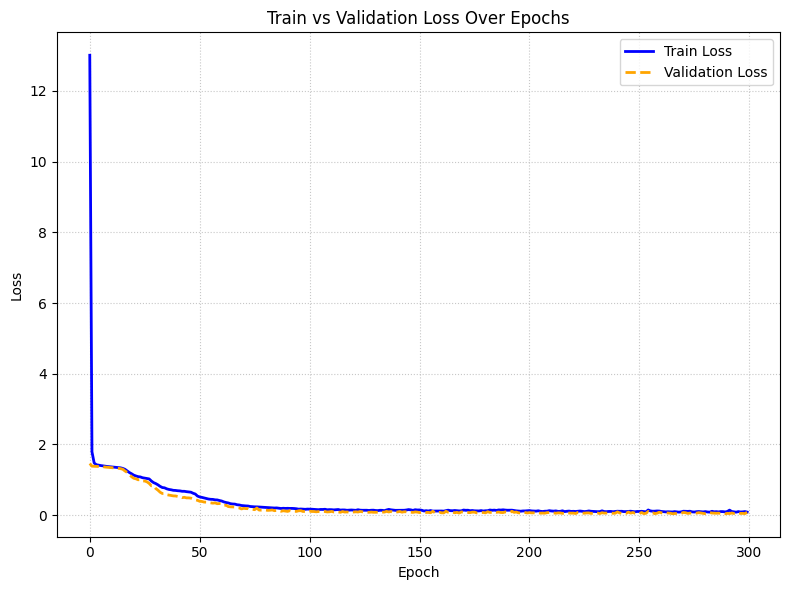

In [380]:
plt.figure(figsize=(8, 6))

# Updated to use val_losses to match the previous cell's corrections!
plt.plot(train_losses, label="Train Loss", color='blue', linewidth=2)
plt.plot(val_losses, label="Validation Loss", color='orange', linewidth=2, linestyle='--')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss Over Epochs")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Testing

In [381]:
# 1. Safely copy the test set to avoid modifying the original data
testing_prep = testing.copy()

# 2. Apply the dynamic mapping we generated earlier
testing_prep["label"] = testing_prep["label"].map(mapping)

# 3. Setup Visualization Constants
# Define display labels FIRST
display_labels = ["Paper", "Rock", "Scissors", "None"]
num_classes = len(display_labels)

# Use modern matplotlib syntax
cmap = plt.colormaps.get_cmap("gist_rainbow")

# Generate exactly 4 colors based on the length of your display labels
colors = cmap(np.linspace(0, 1, num_classes))

# Set confidence threshold for predictions
conf_thres = 0.7

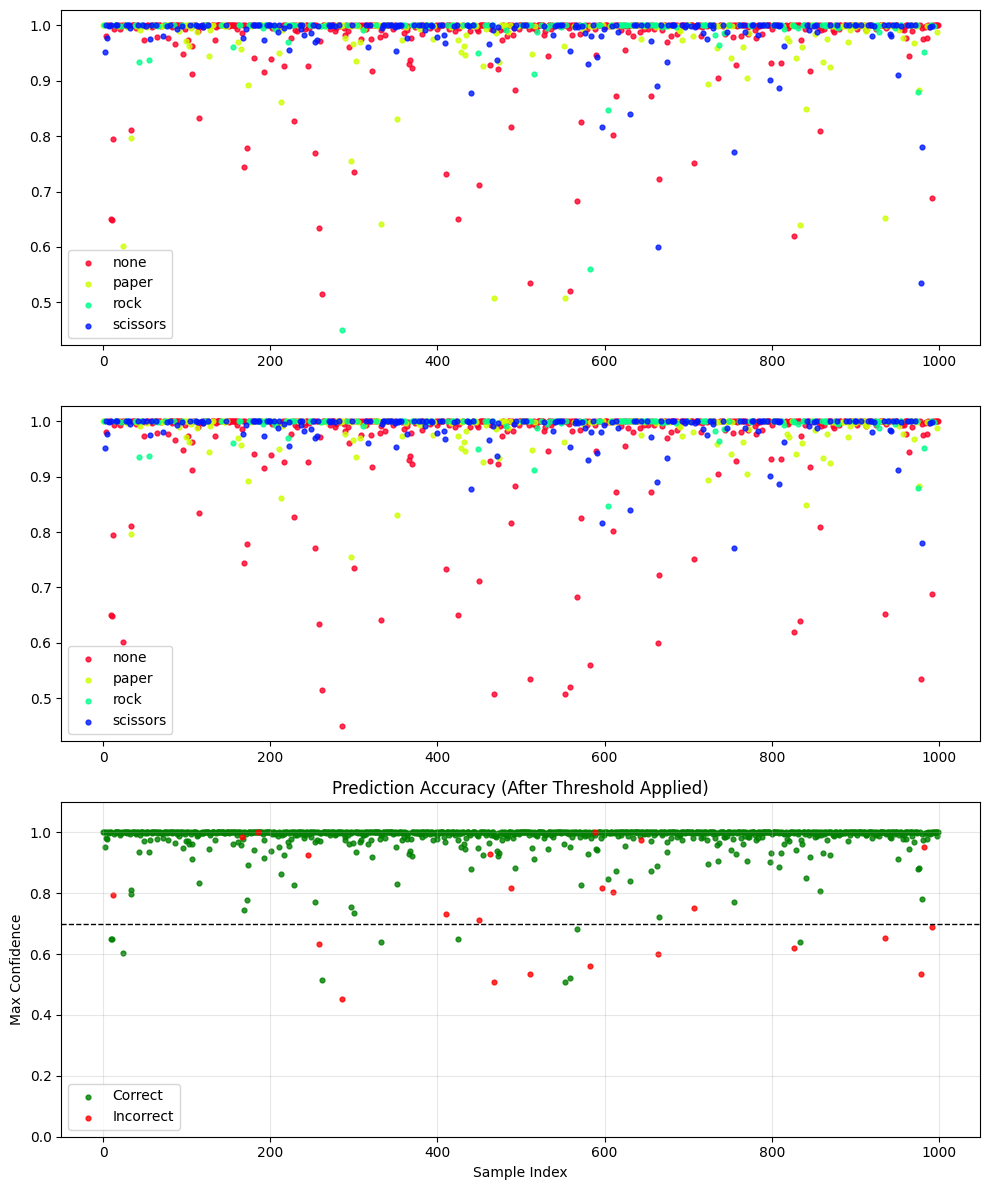

In [382]:
# ------------------------
# Prepare Test Features
# ------------------------
true_labels1 = testing_prep['label'] # Using the safely copied dataframe from the previous cell
X_features = testing_prep.drop(columns=['label'])

# Vectorized coercion (much faster than a for loop)
X_features = X_features.apply(pd.to_numeric, errors='coerce').fillna(0)

# Align columns with the training data's features (Update the variable name here if needed)
# Use the pandas DataFrame from earlier in your pipeline
X_features = X_features[X_train.columns]

X_new = torch.tensor(X_features.values, dtype=torch.float32).to(device)

# ------------------------
# Inference
# ------------------------
model_4.eval()
with torch.inference_mode():
    new_logits = model_4(X_new)
    new_probs = torch.softmax(new_logits, dim=1)
    # Get the highest probability and the corresponding class index
    max_probs, max_classes = torch.max(new_probs, dim=1)

# Convert to numpy for matplotlib and thresholding
max_probs = max_probs.cpu().numpy()
max_classes = max_classes.cpu().numpy()
true_numeric1 = true_labels1.reset_index(drop=True).values

# ------------------------
# Prepare thresholded predictions (FIXED LOGIC)
# ------------------------
pred_classes_thresh = max_classes.copy()

# Look up the actual integer mapped to 'none' in your dictionary (it should be 3)
existing_none_idx = mapping.get('none', 3) 

# If confidence is below threshold, set prediction to the existing 'none' class
pred_classes_thresh[max_probs < conf_thres] = existing_none_idx

# ------------------------
# Create 3 subplots
# ------------------------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# Ensure max_classes is integers, not floats
max_classes = max_classes.astype(int)
pred_classes_thresh = pred_classes_thresh.astype(int)

# ------------------------
# Plot 1: Updated Loop
# ------------------------
for label, class_idx in mapping.items(): # mapping.items() gives (str, int)
    mask = (max_classes == class_idx)
    indices = np.flatnonzero(mask)
    
    # We use the label in the scatter call so the legend picks it up
    color = plt.colormaps.get_cmap("gist_rainbow")(class_idx / len(mapping))
    
    if len(indices) > 0:
        ax1.scatter(
            indices, 
            max_probs[indices], 
            s=12, 
            alpha=0.8, 
            label=label, # This is what the legend looks for!
            color=color
        )

# Check if anything was actually plotted before calling legend to avoid the warning
if ax1.get_legend_handles_labels()[0]:
    ax1.legend()

# ------------------------
# Plot 2: Updated Loop
# ------------------------
for label, class_idx in mapping.items():
    mask = (pred_classes_thresh == class_idx)
    indices = np.flatnonzero(mask)
    
    color = plt.colormaps.get_cmap("gist_rainbow")(class_idx / len(mapping))
    
    if len(indices) > 0:
        ax2.scatter(
            indices, 
            max_probs[indices], 
            s=12, 
            alpha=0.8, 
            label=label, 
            color=color
        )

if ax2.get_legend_handles_labels()[0]:
    ax2.legend()
# ------------------------
# Plot 3: Correct vs Incorrect (threshold applied)
# ------------------------
correct_mask_thresh = pred_classes_thresh == true_numeric1
incorrect_mask_thresh = pred_classes_thresh != true_numeric1

correct_idx = np.flatnonzero(correct_mask_thresh)
incorrect_idx = np.flatnonzero(incorrect_mask_thresh)

ax3.scatter(correct_idx, max_probs[correct_idx], s=12, alpha=0.8, label="Correct", color="green")
ax3.scatter(incorrect_idx, max_probs[incorrect_idx], s=12, alpha=0.8, label="Incorrect", color="red")

ax3.set_xlabel("Sample Index")
ax3.set_ylabel("Max Confidence")
ax3.set_ylim(0, 1.1)
ax3.set_title("Prediction Accuracy (After Threshold Applied)")
ax3.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Live Data Sim

In [383]:
# 1. Load and clean
df_test = pd.read_csv("data/Glove_v2_norm/output_norm_test.csv", sep=",")
df_test = df_test.iloc[1:].copy() # Use .copy() to avoid SettingWithCopyWarnings

# 2. Safe dropping and renaming
# Replace '0' with the actual column name if it's a string like "Time"
df_test = df_test.drop(columns=[df_test.columns[0]], errors='ignore') 
df_test.rename(columns={df_test.columns[-1]: 'label'}, inplace=True)

# 3. Bulletproof label mapping
# mapping2 = {'paper': 0, 'rock': 1, 'scissors': 2, 'none': 3}
mapping2 = mapping.copy()
# mapping2["none"] = 3
df_test["label"] = df_test["label"].astype(str).str.strip().str.lower().map(mapping2)

# 4. Visualization Setup (ORDER MATTERS!)
display_labels = ["Paper", "Rock", "Scissors", "None"]
num_classes = len(display_labels)
conf_thres = 0.7

# Generate exactly 4 colors
cmap = plt.colormaps.get_cmap("gist_rainbow")
colors = cmap(np.linspace(0, 1, num_classes))

# Assign to your testing variable
testing2 = df_test

In [384]:
# df_test.head(20)

In [385]:
# from sklearn.preprocessing import MinMaxScaler

# # Separate features and labels from df_test
# features_to_scale = testing2.drop(columns=['label'])
# labels_df_test = testing2['label']

# Initialize MinMaxScaler
# scaler = MinMaxScaler()

# Fit and transform the features
# scaled_features = scaler.fit_transform(features_to_scale)

# Create a DataFrame with the scaled features
# df_test_normalized = pd.DataFrame(scaled_features, columns=features_to_scale.columns)

# Add the label column back to the normalized DataFrame
# df_test_normalized['label'] = labels_df_test.reset_index(drop=True)

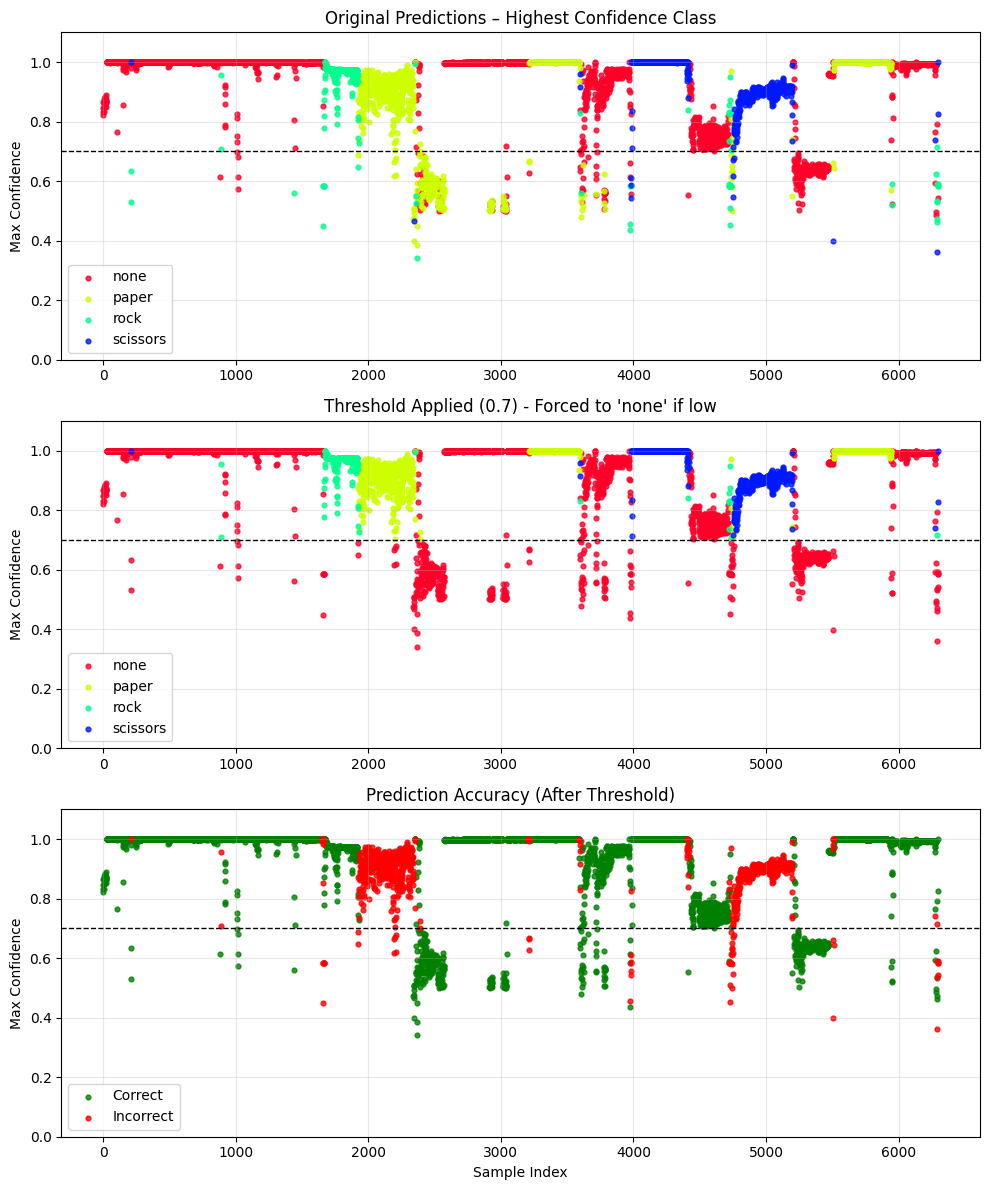

In [386]:
# ------------------------
# 1. Prepare Test Features
# ------------------------
# Use the testing2 dataframe we loaded from the new CSV
true_labels2 = testing2["label"]
X_features = testing2.drop(columns=['label'], errors='ignore')

# Vectorized coercion to ensure all sensor data is numeric
X_features = X_features.apply(pd.to_numeric, errors='coerce').fillna(0)

# CRITICAL: Align columns with your ORIGINAL training features
# Replace 'X_train' with whatever your training DataFrame was named (e.g., 'df_train' or 'data')
X_features = X_features[X_train.columns] 

# Convert to PyTorch tensor and move to GPU/CPU
X_new = torch.tensor(X_features.values, dtype=torch.float32).to(device)

# ------------------------
# 2. Inference
# ------------------------
model_4.eval()
with torch.inference_mode():
    new_logits = model_4(X_new)
    new_probs = torch.softmax(new_logits, dim=1)
    # Get the highest probability and the corresponding class index
    max_probs, max_classes = torch.max(new_probs, dim=1)

# Convert tensors to CPU numpy for thresholding and plotting
max_probs = max_probs.cpu().numpy()
max_classes = max_classes.cpu().numpy().astype(int)
true_numeric2 = true_labels2.reset_index(drop=True).values.astype(int)

# ------------------------
# 3. Thresholding Logic (Fixed)
# ------------------------
pred_classes_thresh = max_classes.copy()
# Map low confidence to the EXISTING 'none' index (usually 3)
none_class_idx = mapping.get('none', 3) 
pred_classes_thresh[max_probs < conf_thres] = none_class_idx

# ------------------------
# 4. Visualization (3 Subplots)
# ------------------------
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))
cmap = plt.colormaps.get_cmap("gist_rainbow")

# Plot 1: Raw Predictions
for label, class_idx in mapping.items():
    mask = (max_classes == class_idx)
    indices = np.flatnonzero(mask)
    if len(indices) == 0: continue
    
    color = cmap(class_idx / len(mapping))
    ax1.scatter(indices, max_probs[indices], s=12, alpha=0.8, label=label, color=color)

ax1.set_ylabel("Max Confidence")
ax1.set_ylim(0, 1.1)
ax1.set_title("Original Predictions – Highest Confidence Class")
ax1.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Thresholded predictions
for label, class_idx in mapping.items():
    mask = (pred_classes_thresh == class_idx)
    indices = np.flatnonzero(mask)
    if len(indices) == 0: continue
    
    color = cmap(class_idx / len(mapping))
    ax2.scatter(indices, max_probs[indices], s=12, alpha=0.8, label=label, color=color)

ax2.set_ylabel("Max Confidence")
ax2.set_ylim(0, 1.1)
ax2.set_title(f"Threshold Applied ({conf_thres}) - Forced to 'none' if low")
ax2.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax2.legend()
ax2.grid(alpha=0.3)

# Plot 3: Accuracy (Correct vs Incorrect)
correct_mask = (pred_classes_thresh == true_numeric2)
incorrect_mask = (pred_classes_thresh != true_numeric2)

ax3.scatter(np.flatnonzero(correct_mask), max_probs[correct_mask], 
            s=12, alpha=0.8, label="Correct", color="green")
ax3.scatter(np.flatnonzero(incorrect_mask), max_probs[incorrect_mask], 
            s=12, alpha=0.8, label="Incorrect", color="red")

ax3.set_xlabel("Sample Index")
ax3.set_ylabel("Max Confidence")
ax3.set_ylim(0, 1.1)
ax3.set_title("Prediction Accuracy (After Threshold)")
ax3.axhline(y=conf_thres, color='black', linestyle='--', linewidth=1)
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluation


## Confusion Matrix

In [387]:
true_numeric = true_numeric2

In [388]:
print(f"Number of NaNs in true_numeric: {np.isnan(true_numeric).sum()}")

Number of NaNs in true_numeric: 0


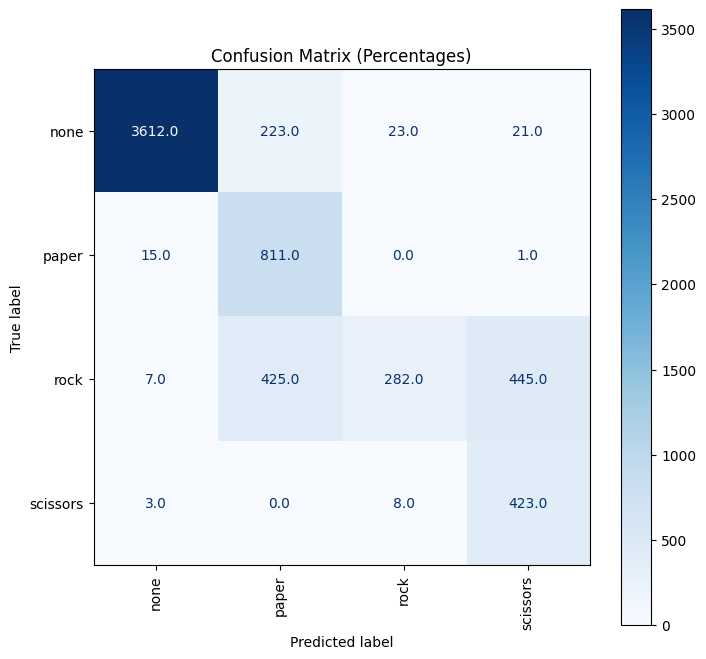

In [389]:
# 1. Ensure numeric types and clean NaNs
valid_mask = ~np.isnan(true_numeric2) # Using 'true_numeric2' from your latest test
true_numeric_clean = true_numeric2[valid_mask].astype(int)
max_classes_clean = max_classes[valid_mask].astype(int)

# 2. Calculate the matrix
# Use 'labels' to force the matrix to include all classes even if they weren't predicted
class_indices = list(range(len(mapping)))
cm = confusion_matrix(true_numeric_clean, max_classes_clean, labels=class_indices)

# 3. Plot with normalization ('true' normalizes by rows/actual classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=list(mapping.keys())
)

# Plotting with percentages makes it much easier to read
disp.plot(cmap='Blues', ax=ax, values_format='.1f', xticks_rotation='vertical')

plt.title("Confusion Matrix (Percentages)")
plt.show()

In [390]:
print("Average Confidence per Predicted Class:\n")

# Use the actual mapping to stay consistent with your 4 classes
for class_name, class_idx in mapping.items():
    # 1. Create a mask for samples assigned to this class (after thresholding)
    class_mask = (pred_classes_thresh == class_idx)

    # 2. Extract the original probabilities for these samples
    confidences_for_class = max_probs[class_mask]

    if len(confidences_for_class) > 0:
        avg_confidence = np.mean(confidences_for_class)
        print(f"{class_name.capitalize()}: {avg_confidence:.4f} (Samples: {len(confidences_for_class)})")
    else:
        print(f"{class_name.capitalize()}: No predictions made for this class.")

Average Confidence per Predicted Class:

None: 0.9057 (Samples: 3914)
Paper: 0.9653 (Samples: 1232)
Rock: 0.9545 (Samples: 273)
Scissors: 0.9418 (Samples: 880)


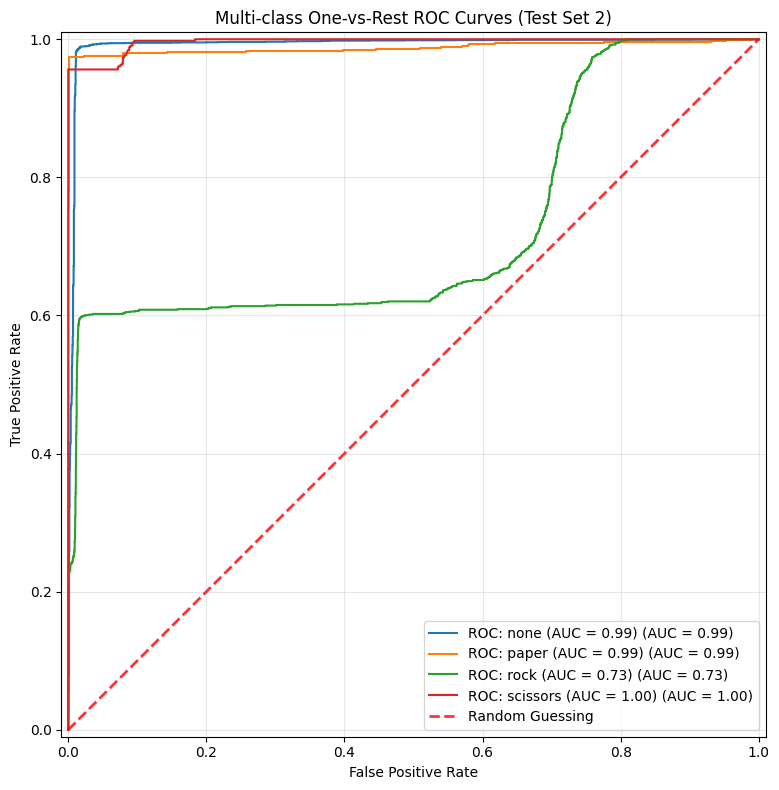

In [391]:
# ------------------------
# 1. Prepare Features & Labels
# ------------------------
# Use the mapped labels from your second test set
true_labels = true_numeric2 

X_features = testing2.copy()
X_features = X_features.drop(columns=['label'], errors='ignore')

# Vectorized numeric conversion
X_features = X_features.apply(pd.to_numeric, errors='coerce').fillna(0)

# CRITICAL: Align columns using the original training DataFrame template
# Change 'X_train' to whatever your training features were named (e.g. df_train)
X_features = X_features[X_train.columns] 

# Convert to Tensor for the model
X_new = torch.tensor(X_features.values, dtype=torch.float32).to(device)

# ------------------------
# 2. Model Inference
# ------------------------
model_4.eval()
with torch.inference_mode():
    new_logits = model_4(X_new)
    # ROC curves require probabilities, so we MUST use softmax
    new_probs = torch.softmax(new_logits, dim=1)

# ------------------------
# 3. Data Prep for ROC
# ------------------------
# Move probabilities to CPU numpy for Scikit-Learn
y_score = new_probs.cpu().numpy()

# Convert true labels to One-Hot encoding (Required for Multi-class ROC)
label_binarizer = LabelBinarizer().fit(true_labels)
y_onehot_test = label_binarizer.transform(true_labels)

# ------------------------
# 4. Plotting One-vs-Rest ROC Curves
# ------------------------
fig, ax = plt.subplots(figsize=(10, 8))

# Get the list of class names from your mapping (e.g., ['rock', 'paper', ...])
class_names = list(mapping.keys())

for class_id, class_name in enumerate(class_names):
    # Calculate specific AUC for this class to put in the legend
    fpr, tpr, _ = roc_curve(y_onehot_test[:, class_id], y_score[:, class_id])
    roc_auc = auc(fpr, tpr)
    
    # Plot the curve for this class
    RocCurveDisplay.from_predictions(
        y_onehot_test[:, class_id],
        y_score[:, class_id],
        name=f"ROC: {class_name} (AUC = {roc_auc:.2f})",
        ax=ax,
        plot_chance_level=False # We will add a custom one for better styling
    )

# Add a professional "Chance Level" diagonal line
ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='red', label='Random Guessing', alpha=.8)

# Styling
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Multi-class One-vs-Rest ROC Curves (Test Set 2)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## K-Fold


   FOLD 1 / 5
   Epoch: 0 | Train Loss: 89.42638, Acc: 25.04% | Test Loss: 72.61356, Acc: 25.00%
   Epoch: 100 | Train Loss: 1.46281, Acc: 25.01% | Test Loss: 1.39619, Acc: 25.02%
   Epoch: 200 | Train Loss: 1.40648, Acc: 25.00% | Test Loss: 1.39214, Acc: 25.00%
   Epoch: 299 | Train Loss: 1.39889, Acc: 25.00% | Test Loss: 1.38934, Acc: 25.00%

   FOLD 2 / 5
   Epoch: 0 | Train Loss: 57.23353, Acc: 25.02% | Test Loss: 38.02732, Acc: 24.83%
   Epoch: 100 | Train Loss: 1.70511, Acc: 25.40% | Test Loss: 1.39925, Acc: 24.94%
   Epoch: 200 | Train Loss: 1.44106, Acc: 24.99% | Test Loss: 1.38066, Acc: 25.06%
   Epoch: 299 | Train Loss: 1.35684, Acc: 28.76% | Test Loss: 1.31554, Acc: 29.95%

   FOLD 3 / 5
   Epoch: 0 | Train Loss: 50.92678, Acc: 25.27% | Test Loss: 45.01817, Acc: 25.00%
   Epoch: 100 | Train Loss: 1.48861, Acc: 24.90% | Test Loss: 1.38867, Acc: 25.01%
   Epoch: 200 | Train Loss: 1.40523, Acc: 25.01% | Test Loss: 1.38756, Acc: 25.01%
   Epoch: 299 | Train Loss: 1.39445, Acc: 

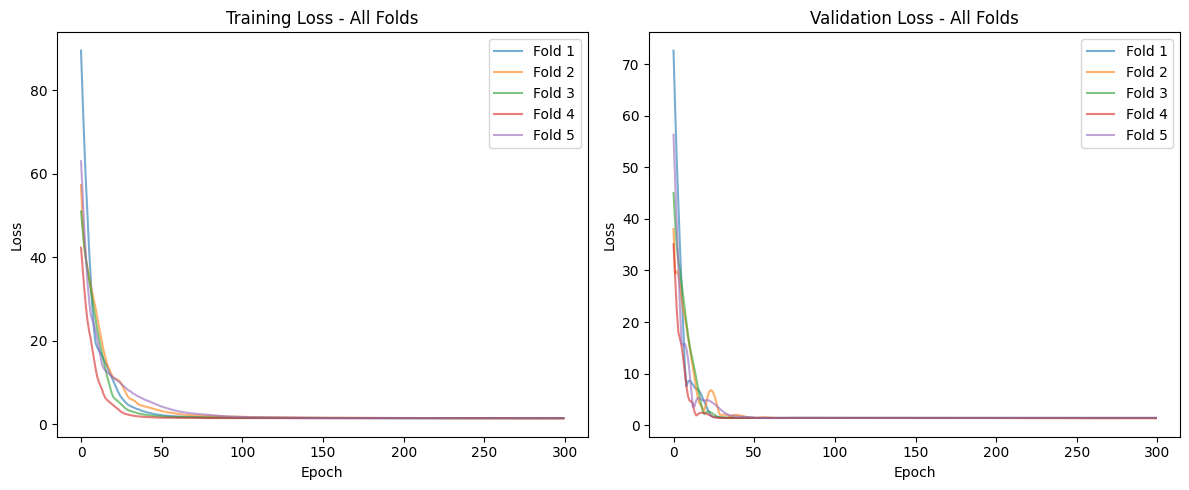


   K-FOLD FINAL SUMMARY
   Fold 1: Train 25.00%  |  Test 25.00%
   Fold 2: Train 28.76%  |  Test 29.95%
   Fold 3: Train 25.03%  |  Test 25.00%
   Fold 4: Train 24.99%  |  Test 25.00%
   Fold 5: Train 25.15%  |  Test 25.05%

   Mean Test Acc : 26.00% (+/- 1.97%)
   Mean F1-Score : 0.120
   Mean Precision: 0.234
   Mean Recall   : 0.260


In [392]:
# Ensure reproducibility
torch.manual_seed(SEED)

# 1. Initialize storage for metrics
all_train_losses = [] 
all_test_losses  = [] 
fold_train_accs = [] 
fold_test_accs = [] 
fold_precisions = []
fold_recalss = []
fold_f1_scores = []

# Prepare data for StratifiedKFold (requires numpy for indices)
X_np = X.numpy()
y_np = y.numpy()

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# ------------------------
# K-Fold Loop
# ------------------------
for fold, (train_idx, test_idx) in enumerate(skf.split(X_np, y_np)):
    print(f"\n{'='*40}")
    print(f"   FOLD {fold + 1} / {N_FOLDS}")
    print(f"{'='*40}")

    # Split and move to device
    X_train_fold, y_train_fold = X[train_idx].to(device), y[train_idx].long().to(device)
    X_test_fold, y_test_fold   = X[test_idx].to(device), y[test_idx].long().to(device)

    # Re-initialize Model, Loss, and Optimizer for a fresh start each fold
    model = RPSModel(input_features=input_features, output_features=classes).to(device)
    loss_fn = nn.CrossEntropyLoss()
    
    # Using Adam for better stability with unscaled sensor features
    optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

    train_losses_per_epoch = []
    test_losses_per_epoch = []
    
    for epoch in range(EPOCHS):
        ### Training Phase
        model.train()
        y_logits = model(X_train_fold)
        y_pred = torch.argmax(y_logits, dim=1)
        
        loss = loss_fn(y_logits, y_train_fold)
        train_acc = accuracy_fn(y_true=y_train_fold, y_pred=y_pred)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ### Validation/Test Phase (for this fold)
        model.eval()
        with torch.inference_mode():
            test_logits = model(X_test_fold)
            test_pred = torch.argmax(test_logits, dim=1)
            test_loss = loss_fn(test_logits, y_test_fold)
            test_acc = accuracy_fn(y_true=y_test_fold, y_pred=test_pred)

        train_losses_per_epoch.append(loss.item())
        test_losses_per_epoch.append(test_loss.item())

        if epoch % 100 == 0 or epoch == EPOCHS - 1:
            print(f"   Epoch: {epoch} | Train Loss: {loss:.5f}, Acc: {train_acc:.2f}% | Test Loss: {test_loss:.5f}, Acc: {test_acc:.2f}%")

    # Store final metrics for this fold
    all_train_losses.append(train_losses_per_epoch)
    all_test_losses.append(test_losses_per_epoch)
    fold_train_accs.append(train_acc)
    fold_test_accs.append(test_acc)

    # Detailed report for the current fold
    report = classification_report(
        y_test_fold.cpu(), 
        test_pred.cpu(), 
        target_names=list(mapping.keys()), 
        output_dict=True, 
        zero_division=0
    )
    
    fold_precisions.append(report['macro avg']['precision'])
    fold_recalss.append(report['macro avg']['recall'])
    fold_f1_scores.append(report['macro avg']['f1-score'])

# ------------------------
# 5. Visualizing Cross-Validation Progress
# ------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for i, losses in enumerate(all_train_losses):
    plt.plot(losses, label=f'Fold {i+1}', alpha=0.6)
plt.title('Training Loss - All Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
for i, losses in enumerate(all_test_losses):
    plt.plot(losses, label=f'Fold {i+1}', alpha=0.6)
plt.title('Validation Loss - All Folds')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# ------------------------
# 6. Final Summary Statistics
# ------------------------
print(f"\n{'='*40}")
print(f"   K-FOLD FINAL SUMMARY")
print(f"{'='*40}")
for i, (tr, te) in enumerate(zip(fold_train_accs, fold_test_accs)):
    print(f"   Fold {i+1}: Train {tr:.2f}%  |  Test {te:.2f}%")

print(f"\n   Mean Test Acc : {np.mean(fold_test_accs):.2f}% (+/- {np.std(fold_test_accs):.2f}%)")
print(f"   Mean F1-Score : {np.mean(fold_f1_scores):.3f}")
print(f"   Mean Precision: {np.mean(fold_precisions):.3f}")
print(f"   Mean Recall   : {np.mean(fold_recalss):.3f}")

## Summary

In [393]:
print("\n" + "="*50)
print("           FINAL PERFORMANCE SUMMARY")
print("="*50)

# 1. Accuracy Comparison
acc_raw = accuracy_score(true_numeric, max_classes)
acc_thresh = accuracy_score(true_numeric, pred_classes_thresh)

print(f"Overall Accuracy (Raw):         {acc_raw:.4f}")
print(f"Overall Accuracy (Thresholded): {acc_thresh:.4f}")
print(f"F1-Score (Weighted):            {f1_score(true_numeric, max_classes, average='weighted'):.4f}")

# 2. Cross-Validation Results
print(f"\nK-Fold Mean Test Accuracy:      {np.mean(fold_test_accs):.2f}%")
print(f"K-Fold Std Deviation:           {np.std(fold_test_accs):.2f}%")

# 3. Average Confidence (Clean Logic)
print("\n--- Average Confidence per Predicted Class ---")
for class_name, class_idx in mapping.items():
    # Use the thresholded predictions to see how confident the model was for each group
    class_mask = (pred_classes_thresh == class_idx)
    confidences_for_class = max_probs[class_mask]

    if len(confidences_for_class) > 0:
        avg_confidence = np.mean(confidences_for_class)
        print(f"{class_name.capitalize():<10}: {avg_confidence:.4f} (N={len(confidences_for_class)})")
    else:
        print(f"{class_name.capitalize():<10}: No predictions for this class.")


           FINAL PERFORMANCE SUMMARY
Overall Accuracy (Raw):         0.8141
Overall Accuracy (Thresholded): 0.8460
F1-Score (Weighted):            0.7996

K-Fold Mean Test Accuracy:      26.00%
K-Fold Std Deviation:           1.97%

--- Average Confidence per Predicted Class ---
None      : 0.9057 (N=3914)
Paper     : 0.9653 (N=1232)
Rock      : 0.9545 (N=273)
Scissors  : 0.9418 (N=880)


# Which features are the most important?

Baseline Accuracy on Test Set 2: 81.41%


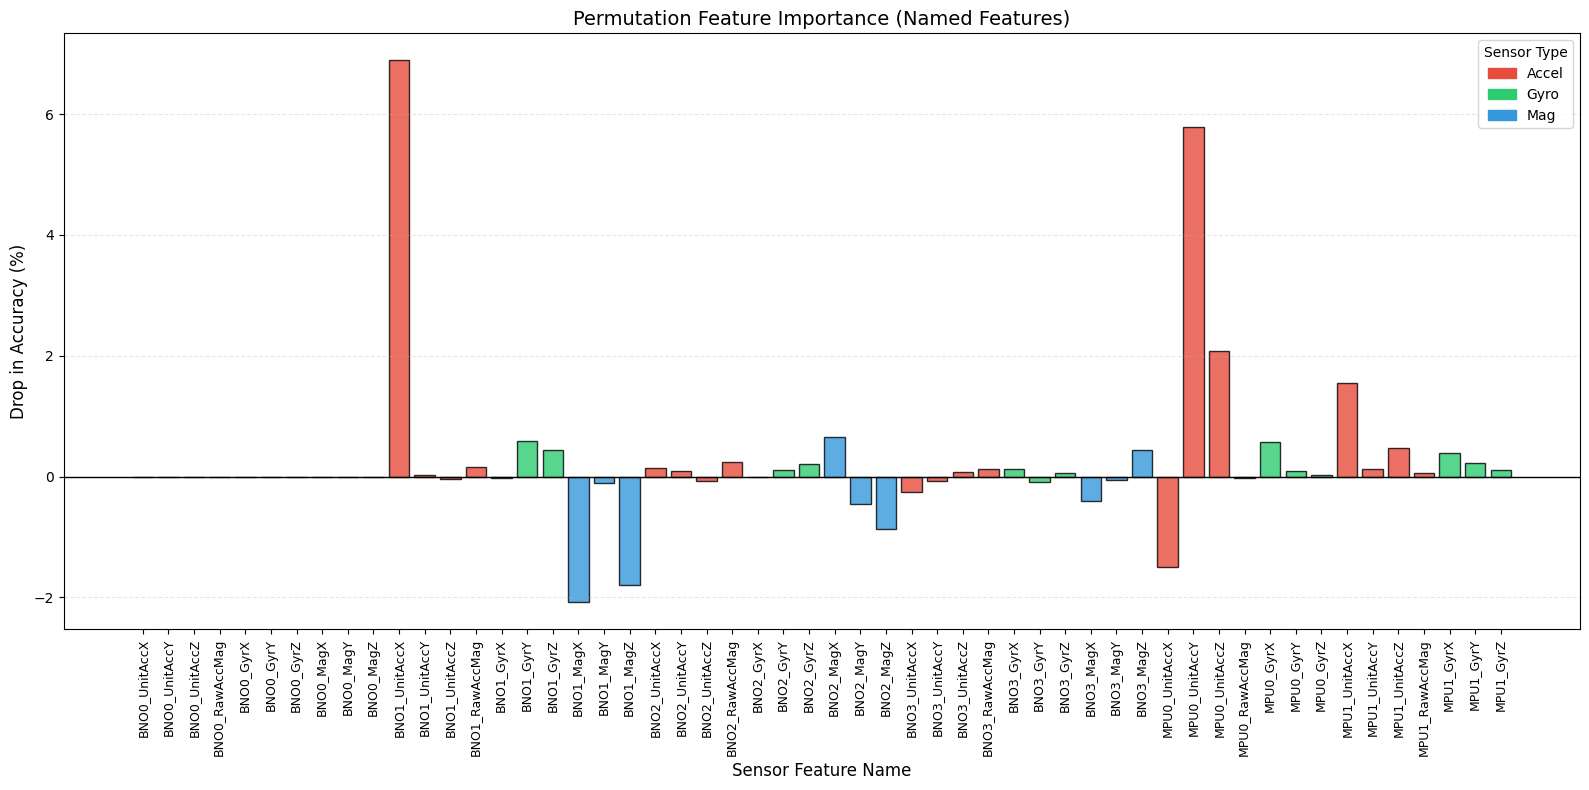


--- Top 5 Most Critical Features ---
1. BNO1_UnitAccX        | Importance Score: 6.8900
2. MPU0_UnitAccY        | Importance Score: 5.7946
3. MPU0_UnitAccZ        | Importance Score: 2.0797
4. MPU1_UnitAccX        | Importance Score: 1.5558
5. BNO2_MagX            | Importance Score: 0.6509


In [394]:
# 1. Prepare Data and Baseline
y_new_tensor = torch.tensor(true_numeric2).long().to(device)
model_4.eval()

with torch.inference_mode():
    baseline_logits = model_4(X_new) 
    baseline_pred = torch.argmax(baseline_logits, dim=1)
    baseline_acc = accuracy_fn(y_true=y_new_tensor, y_pred=baseline_pred)

print(f"Baseline Accuracy on Test Set 2: {baseline_acc:.2f}%")

# 2. Extract Feature Names from your training template
# Using X_train.columns ensures we match the specific indices used by the model
feature_names = list(X_train.columns)
num_features = len(feature_names)

# 3. Calculate Importance per Feature
importances = []
for i in range(num_features):
    X_permuted = X_new.clone()
    X_permuted[:, i] = X_new[torch.randperm(X_new.shape[0]), i] 

    with torch.inference_mode():
        perm_logits = model_4(X_permuted)
        perm_pred = torch.argmax(perm_logits, dim=1)
        perm_acc = accuracy_fn(y_true=y_new_tensor, y_pred=perm_pred)
    
    importances.append(baseline_acc - perm_acc)

# 4. Define Feature Groups (Mappings stay the same, but colors apply to names)
group_colors = {
    'Accel': '#e74c3c', # Red
    'Gyro':  '#2ecc71', # Green
    'Mag':   '#3498db'  # Blue
}

feature_colors = []
for i in range(num_features):
    assigned_color = '#95a5a6' # Default Gray
    name_lower = feature_names[i].lower()
    
    if 'acc' in name_lower:
        assigned_color = group_colors['Accel']
    elif 'gyr' in name_lower:
        assigned_color = group_colors['Gyro']
    elif 'mag' in name_lower:
        assigned_color = group_colors['Mag']
    
    feature_colors.append(assigned_color)

# 5. Plotting with Feature Names
plt.figure(figsize=(16, 8))
plt.bar(feature_names, importances, color=feature_colors, edgecolor='black', alpha=0.8)

plt.xlabel("Sensor Feature Name", fontsize=12)
plt.ylabel("Drop in Accuracy (%)", fontsize=12)
plt.title("Permutation Feature Importance (Named Features)", fontsize=14)
plt.axhline(0, color='black', lw=1)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Rotate labels so they don't overlap
plt.xticks(rotation=90, fontsize=9)

# Custom Legend
handles = [plt.Rectangle((0,0),1,1, color=group_colors[g]) for g in group_colors]
plt.legend(handles, group_colors.keys(), title="Sensor Type", loc='upper right')

plt.tight_layout()
plt.show()

# 6. Print Top 5 Critical Features by Name
sorted_idx = np.argsort(importances)[::-1]
print("\n--- Top 5 Most Critical Features ---")
for i in range(5):
    idx = sorted_idx[i]
    print(f"{i+1}. {feature_names[idx]:<20} | Importance Score: {importances[idx]:.4f}")

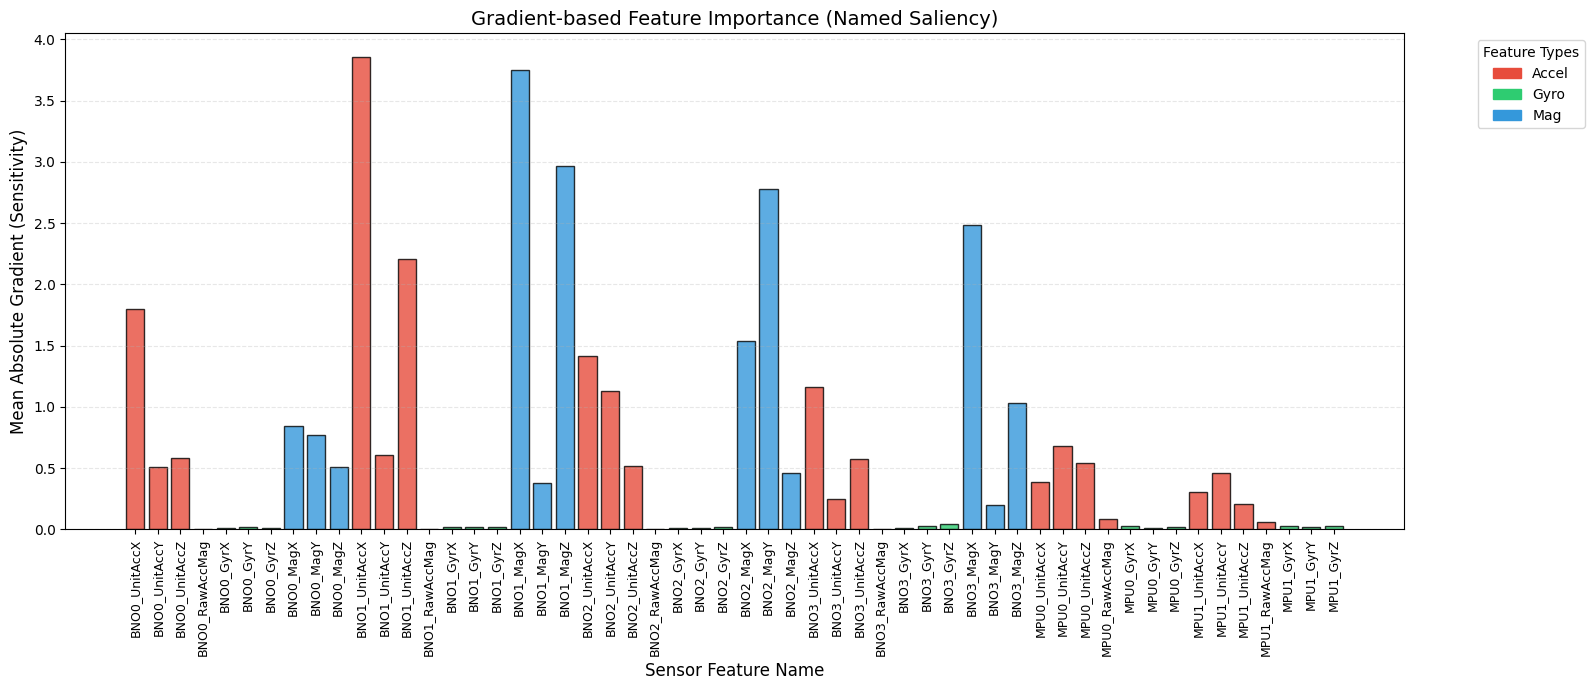


--- Top 5 Features the Model is 'Looking At' (Saliency) ---
1. BNO1_UnitAccX        | Gradient Sensitivity: 3.856907
2. BNO1_MagX            | Gradient Sensitivity: 3.753346
3. BNO1_MagZ            | Gradient Sensitivity: 2.963393
4. BNO2_MagY            | Gradient Sensitivity: 2.779870
5. BNO3_MagX            | Gradient Sensitivity: 2.485027


In [395]:
# 1. Prepare the input for gradients using X_new (Test Set 2)
X_grad_input = X_new.clone().detach().requires_grad_(True)

# 2. Forward pass (Manual eval, no inference_mode because we need the gradient graph)
model_4.eval()
output = model_4(X_grad_input)

# 3. Backward pass on the sum of max logits
# This calculates how much the output 'wiggles' relative to the input features
output.max(dim=1).values.sum().backward()

# 4. Extract Importance (Mean Absolute Gradient)
importances = X_grad_input.grad.abs().mean(dim=0).cpu().detach().numpy()

# 5. Get Feature Names from your original DataFrame
feature_names = list(X_train.columns)
num_features = len(feature_names)

# 6. Define Colors based on feature name keywords
group_colors = {
    'Accel': '#e74c3c', # Red
    'Gyro':  '#2ecc71', # Green
    'Mag':   '#3498db'  # Blue
}

feature_colors = []
for i in range(num_features):
    assigned_color = '#95a5a6' # Default gray
    name_lower = feature_names[i].lower()
    
    if 'acc' in name_lower:
        assigned_color = group_colors['Accel']
    elif 'gyr' in name_lower:
        assigned_color = group_colors['Gyro']
    elif 'mag' in name_lower:
        assigned_color = group_colors['Mag']
        
    feature_colors.append(assigned_color)

# 7. Plotting with Feature Names
plt.figure(figsize=(16, 7))
plt.bar(feature_names, importances, color=feature_colors, edgecolor='black', alpha=0.8)

plt.title("Gradient-based Feature Importance (Named Saliency)", fontsize=14)
plt.xlabel("Sensor Feature Name", fontsize=12)
plt.ylabel("Mean Absolute Gradient (Sensitivity)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Rotate labels for readability
plt.xticks(rotation=90, fontsize=9)

# Create legend
handles = [plt.Rectangle((0,0),1,1, color=group_colors[g]) for g in group_colors]
plt.legend(handles, group_colors.keys(), title="Feature Types", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Print Top 5 Saliency Features
sorted_idx = np.argsort(importances)[::-1]
print("\n--- Top 5 Features the Model is 'Looking At' (Saliency) ---")
for i in range(5):
    idx = sorted_idx[i]
    print(f"{i+1}. {feature_names[idx]:<20} | Gradient Sensitivity: {importances[idx]:.6f}")

In [396]:
# 1. Setup Configuration
PICO_IP = "192.168.4.1" # Change if your Pico is on a different IP
PICO_PORT = "81"
CONFIDENCE_THRESHOLD = 0.8  # Your "None" detection logic
GESTURE_MAP = {0: "Rock", 1: "Paper", 2: "Scissors"}

async def live_inference():
    uri = f"ws://{PICO_IP}:{PICO_PORT}"
    
    try:
        async with websockets.connect(uri) as websocket:
            print(f"Successfully connected to Glove at {uri}")
            print("Starting live gesture recognition... (Press Stop in Jupyter to end)")
            
            model_4.eval() # Ensure model is in evaluation mode
            
            while True:
                # 2. Receive Data
                message = await websocket.recv()
                data = json.loads(message)
                
                # 3. Feature Engineering (Crucial Step)
                # Convert the raw JSON/List into a flat numpy array or list
                # IMPORTANT: The order MUST match your X_train.columns
                raw_features = np.array(list(data.values())).reshape(1, -1)
                
                # Apply your Relative Angle / Unit Vector math here 
                # (Assuming 'data' already contains your hardware-preprocessed features)
                
                # 4. Model Prediction
                input_tensor = torch.tensor(raw_features, dtype=torch.float32).to(device)
                
                with torch.inference_mode():
                    logits = model_4(input_tensor)
                    probs = torch.softmax(logits, dim=1)
                    max_conf, pred_idx = torch.max(probs, dim=1)
                
                # 5. Threshold Logic
                confidence = max_conf.item()
                if confidence > CONFIDENCE_THRESHOLD:
                    gesture = GESTURE_MAP[pred_idx.item()]
                    print(f"Detected: {gesture:10} | Confidence: {confidence:.2f}", end="\r")
                else:
                    print(f"Detected: {'None':10} | Confidence: {confidence:.2f}", end="\r")

    except Exception as e:
        print(f"Connection Error: {e}")

# 6. Run the loop
# In Jupyter, you use await directly if using a modern kernel, 
# otherwise use: asyncio.run(live_inference())
await live_inference()

Connection Error: timed out during opening handshake
